In [3]:
# importing libraries
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np
import missingno as msno

In [4]:
# skincare dataset 
skincare = pd.read_csv("dataset/product_info_skincare.csv")
skincare.columns

Index(['Unnamed: 0', 'product_id', 'product_name', 'brand_id', 'brand_name',
       'loves_count', 'rating', 'reviews', 'size', 'variation_type',
       'variation_value', 'variation_desc', 'ingredients', 'price_usd',
       'value_price_usd', 'sale_price_usd', 'limited_edition', 'new',
       'online_only', 'out_of_stock', 'sephora_exclusive', 'highlights',
       'primary_category', 'secondary_category', 'tertiary_category',
       'child_count', 'child_max_price', 'child_min_price'],
      dtype='object')

In [5]:
# reviews dataset 
revp1 = pd.read_csv("dataset/reviews_0-250_masked.csv")
revp1.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'rating', 'is_recommended', 'helpfulness',
       'total_feedback_count', 'total_neg_feedback_count',
       'total_pos_feedback_count', 'submission_time', 'review_text',
       'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color',
       'product_id', 'product_name', 'brand_name', 'price_usd'],
      dtype='object')

Important columns: 
1. product_name 
2. brand_name 
3. loves_count 
4. rating
5. reviews 
6. ingredients
7. size 
8. price_usd
9. highlights 
10. primary_category 
11. rating 
12. is_recommended 
13. total_feedback_count 
14. total_neg_feedback_count 
15. total_pos_feedback_count 
16. review_text 
17. skin_type 

# Review Dataset 

In [6]:
# checking all parts of reviews
revp2 = pd.read_csv("dataset/reviews_250-500_masked.csv")
revp3 = pd.read_csv("dataset/reviews_500-750_masked.csv")
revp4 = pd.read_csv("dataset/reviews_750-1250_masked.csv")
revp5 = pd.read_csv("dataset/reviews_1250-end_masked.csv")


for part in [revp1, revp2, revp3, revp4, revp5]:
    print(part.shape)


(168432, 19)
(51852, 19)
(29283, 19)
(25040, 19)
(10805, 19)


In [7]:
# combining reviews into one df
review = pd.concat([revp1, revp2])

for part in [revp3, revp4, revp5]:
    review = pd.concat([review, part])
    
print(review.shape)
review.head()

(285412, 19)


,Unnamed: 0.1,Unnamed: 0,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,0,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0
1,1,1,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
2,2,2,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
3,3,3,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
4,4,4,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0


In [8]:
review.drop(['Unnamed: 0.1', 'Unnamed: 0'], axis = 1, inplace = True)

In [9]:
review.head()

,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0
1,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
2,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
3,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
4,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0


<Axes: >

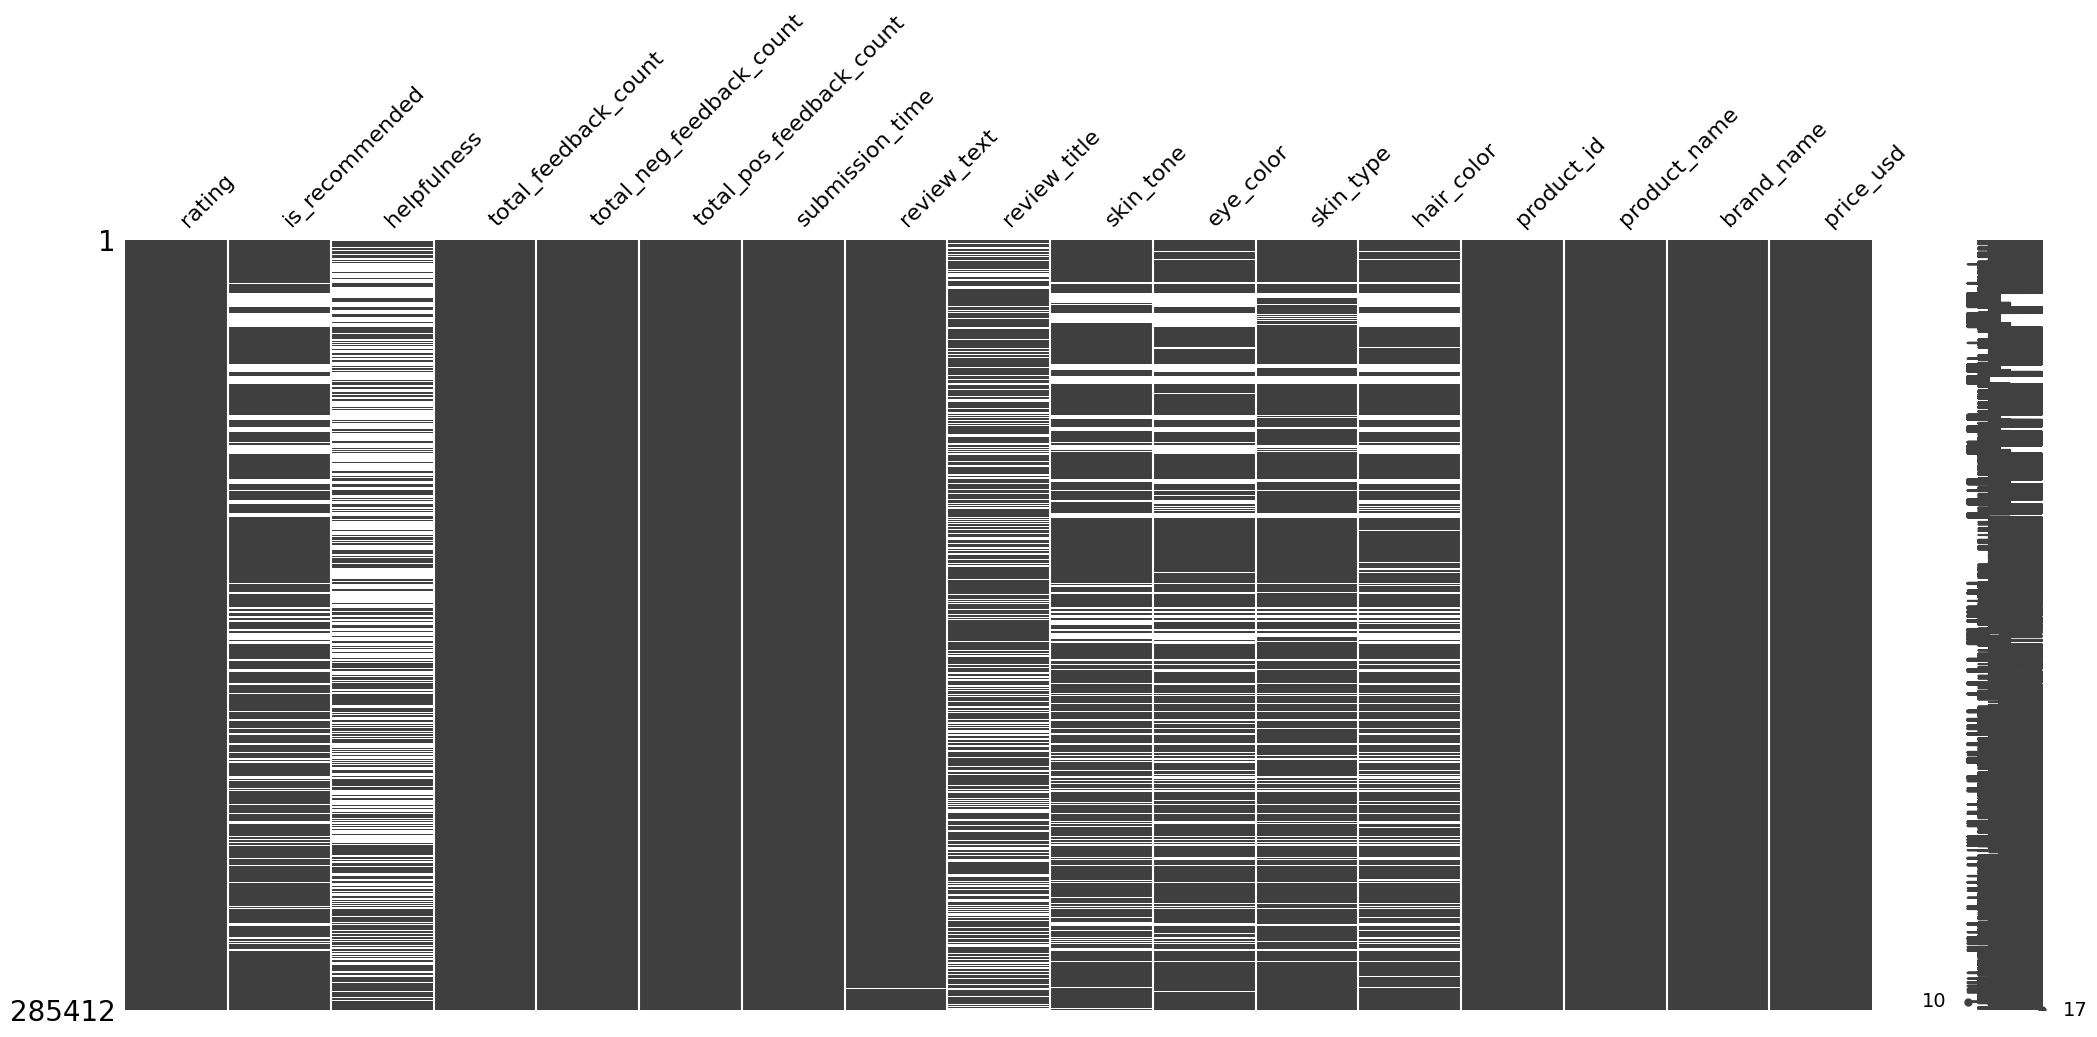

In [10]:
msno.matrix(review)

In [11]:
review.isna().sum()/review.shape[0]

rating                      0.000000
is_recommended              0.200524
helpfulness                 0.540699
total_feedback_count        0.000000
total_neg_feedback_count    0.000000
total_pos_feedback_count    0.000000
submission_time             0.000000
review_text                 0.001209
review_title                0.279224
skin_tone                   0.193496
eye_color                   0.237362
skin_type                   0.129196
hair_color                  0.249047
product_id                  0.000000
product_name                0.000000
brand_name                  0.000000
price_usd                   0.000000
dtype: float64

In [12]:
review.drop(['helpfulness', 'review_title'], axis = 1, inplace = True)

In [13]:
review.isna().sum()/review.shape[0]

rating                      0.000000
is_recommended              0.200524
total_feedback_count        0.000000
total_neg_feedback_count    0.000000
total_pos_feedback_count    0.000000
submission_time             0.000000
review_text                 0.001209
skin_tone                   0.193496
eye_color                   0.237362
skin_type                   0.129196
hair_color                  0.249047
product_id                  0.000000
product_name                0.000000
brand_name                  0.000000
price_usd                   0.000000
dtype: float64

<Axes: >

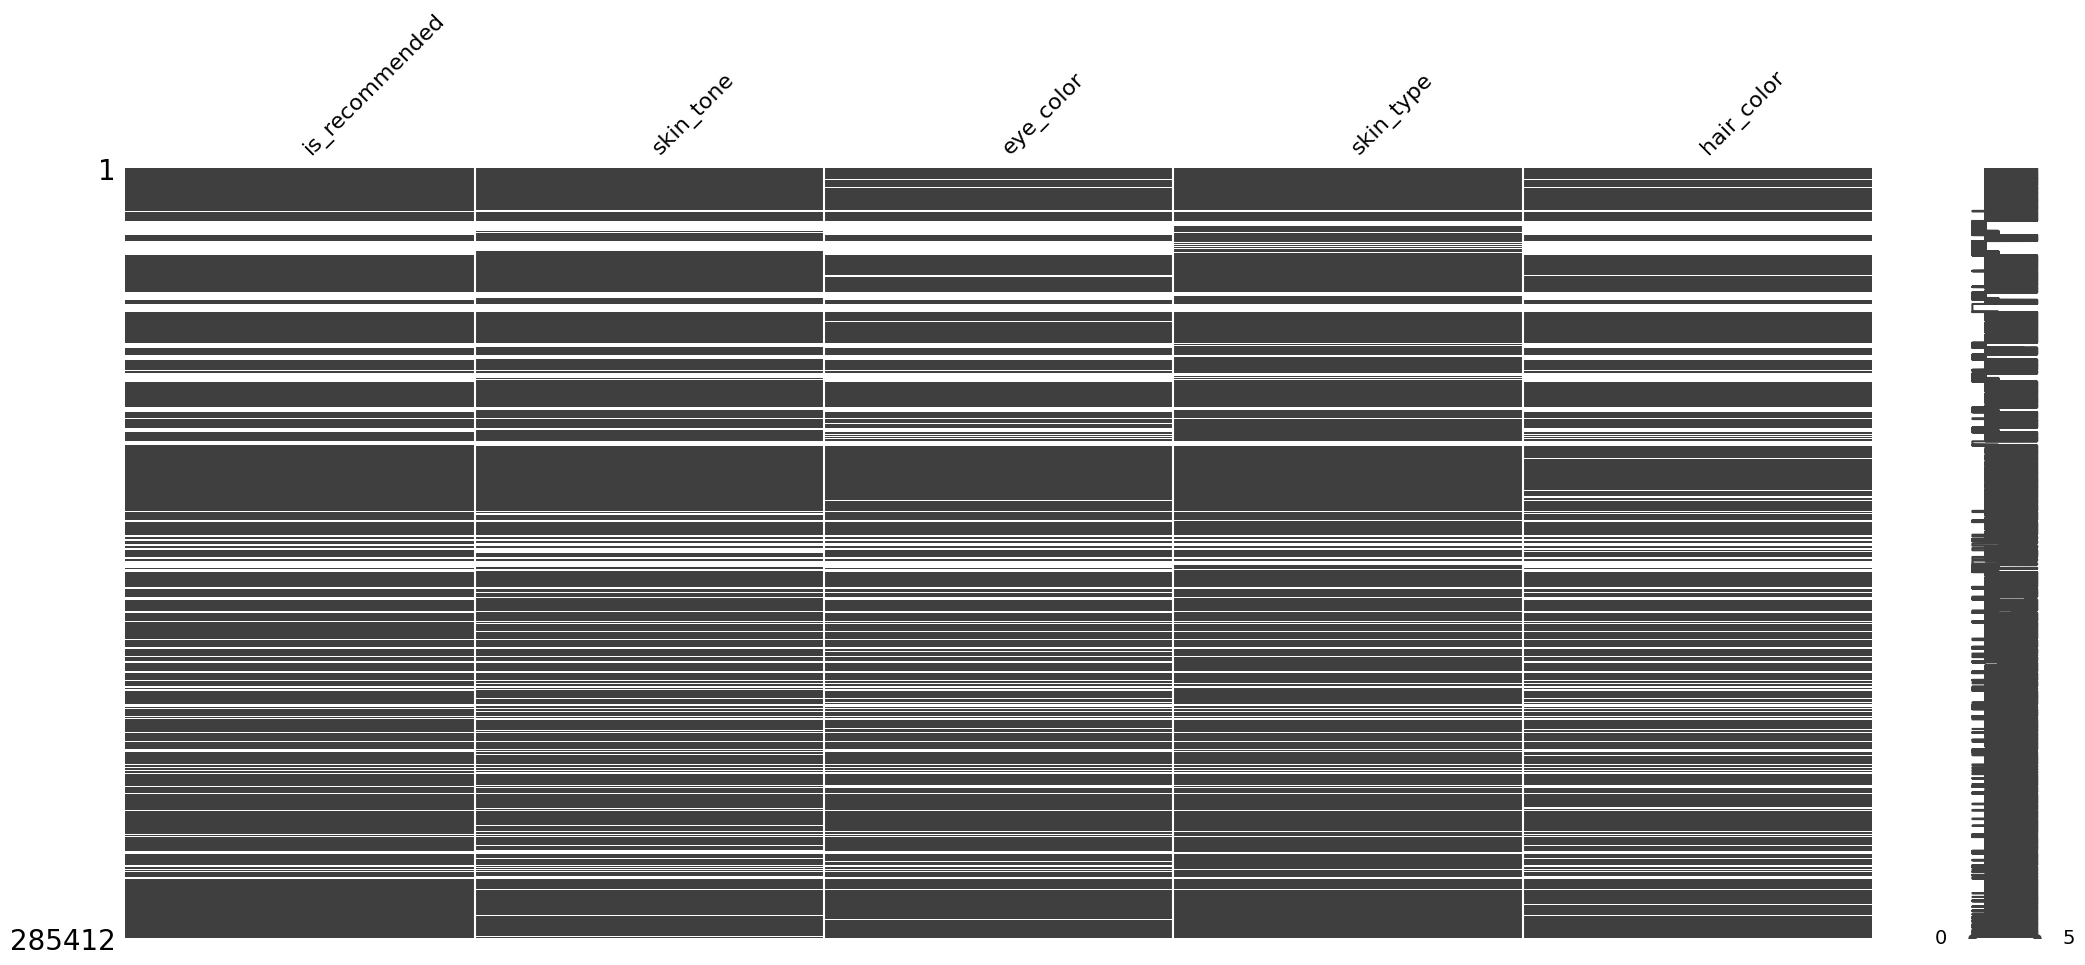

In [14]:
msno.matrix(review[['is_recommended', 'skin_tone', 'eye_color', 'skin_type', 'hair_color']])

In [15]:
review[review['is_recommended'].isna() & review['skin_tone'].isna() & review['eye_color'].isna() & review['skin_type'].isna() & review['hair_color'].isna()].shape[0]/review.shape[0]

0.10988325648536151

<Axes: >

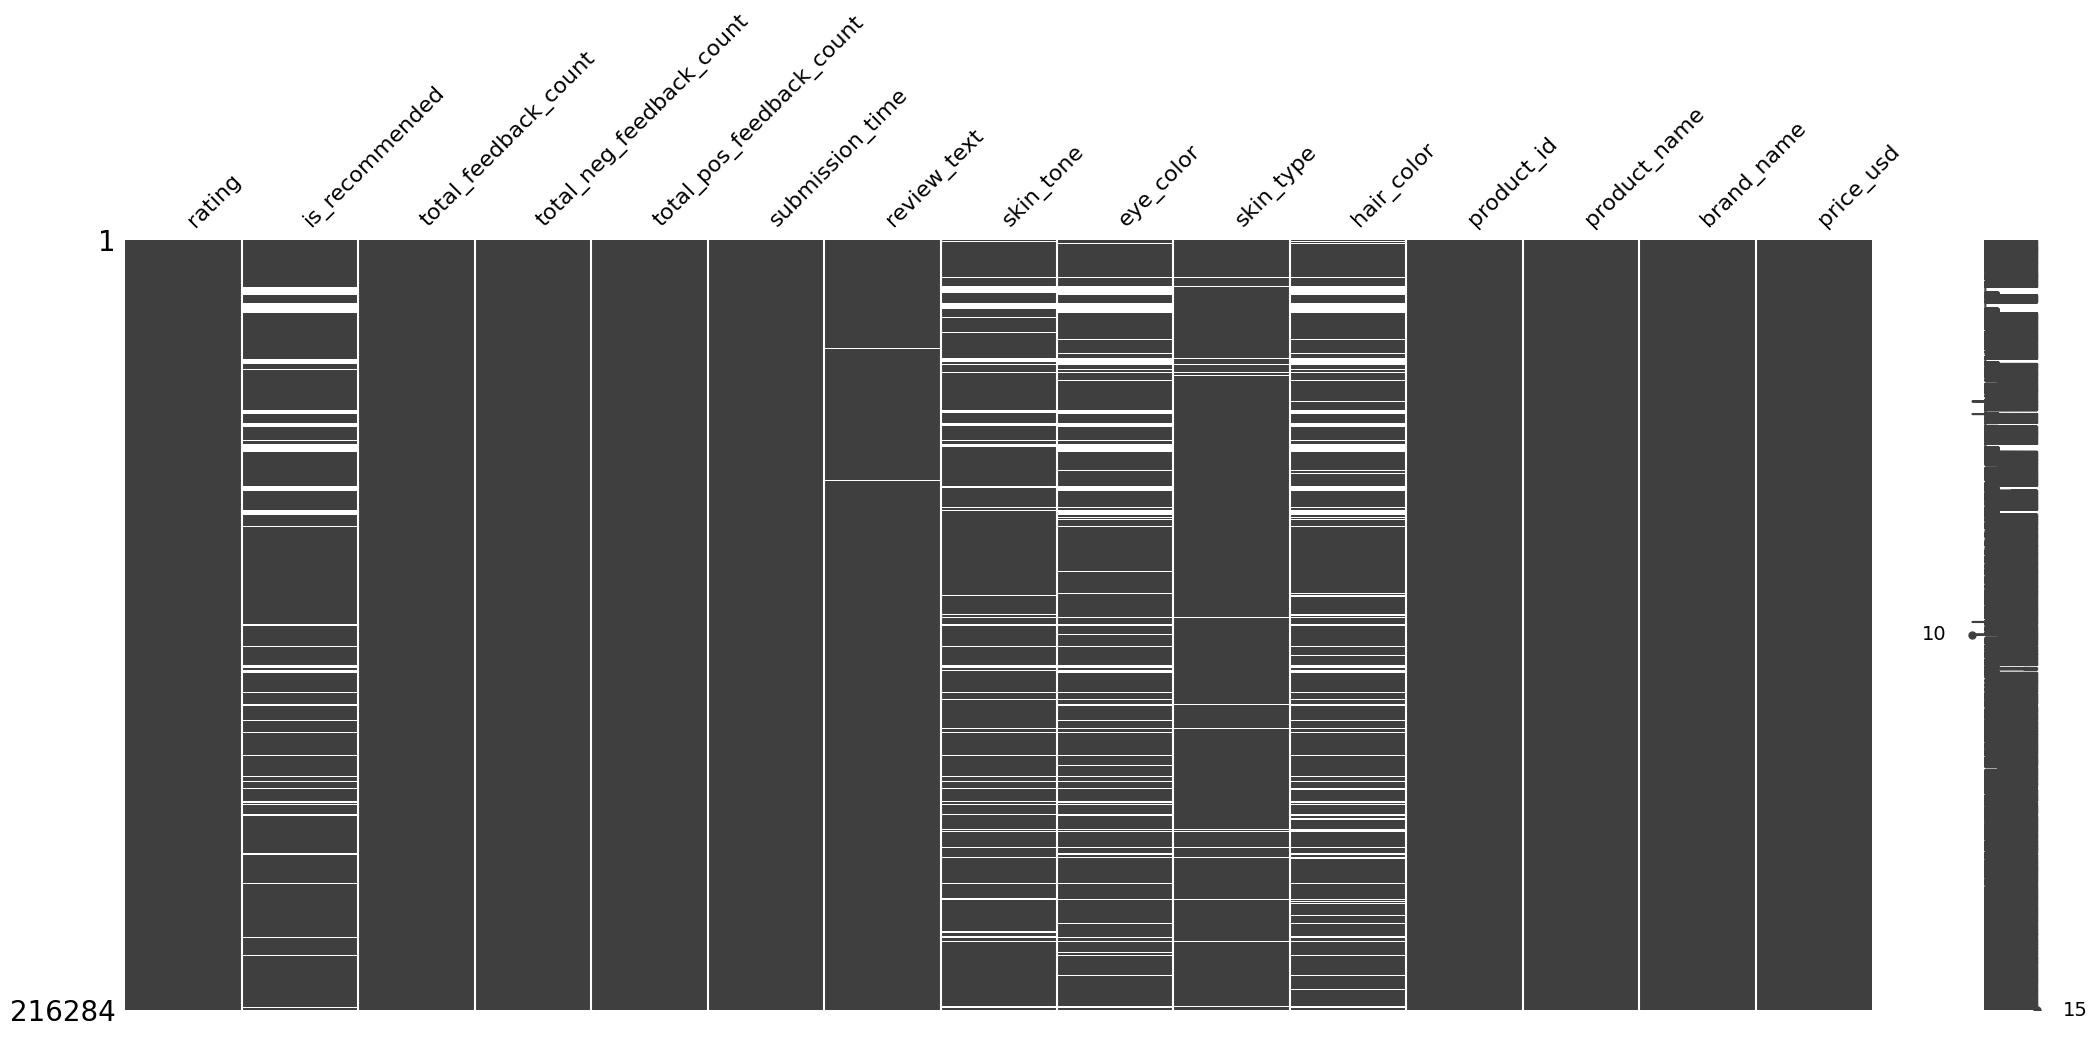

In [16]:
rows_to_drop = review[review['is_recommended'].isna() & review['skin_tone'].isna() & review['eye_color'].isna() & review['skin_type'].isna() & review['hair_color'].isna()].index

review = review.drop(rows_to_drop)
msno.matrix(review)

<Axes: >

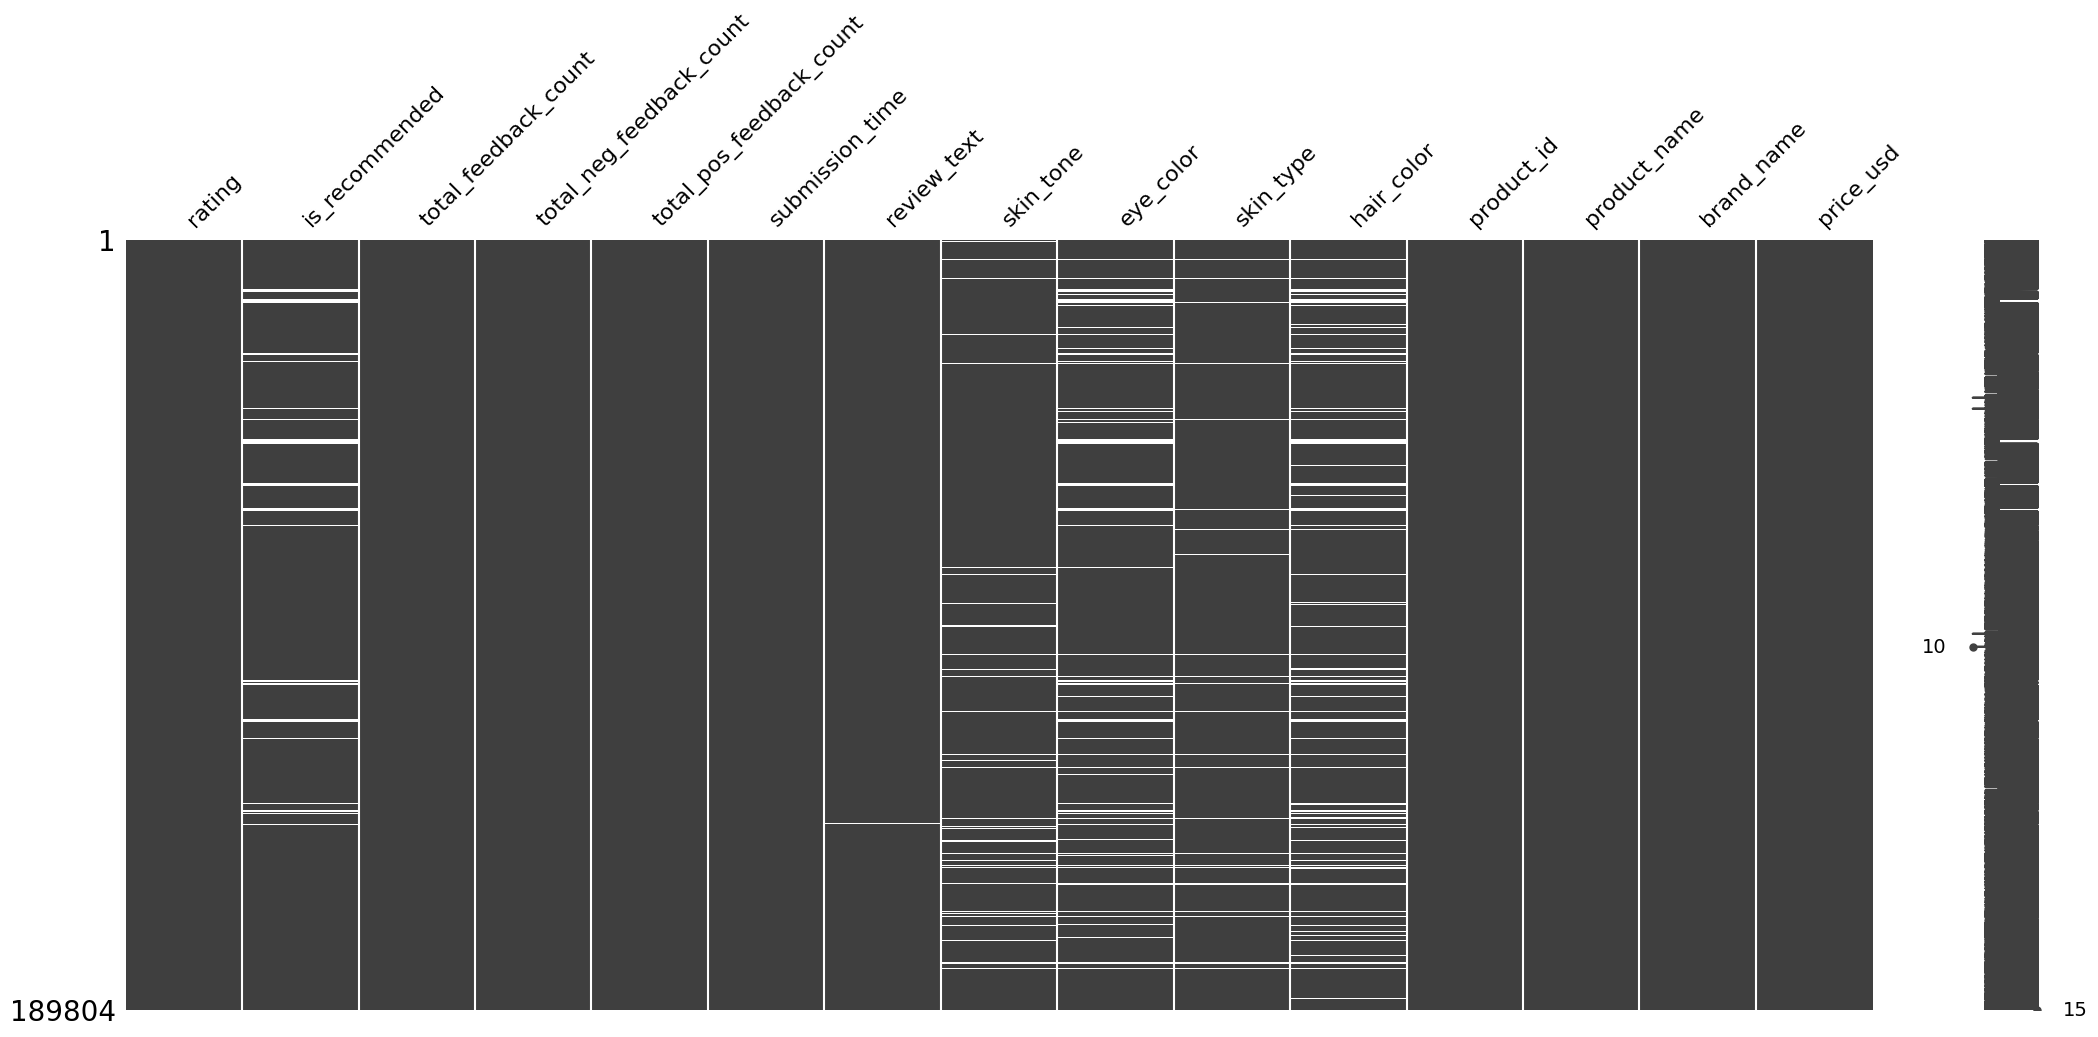

In [17]:
rows_to_drop2 = review[review['is_recommended'].isna() & review['skin_tone'].isna() & review['eye_color'].isna() & review['hair_color'].isna()].index

review = review.drop(rows_to_drop2)
msno.matrix(review)

<Axes: >

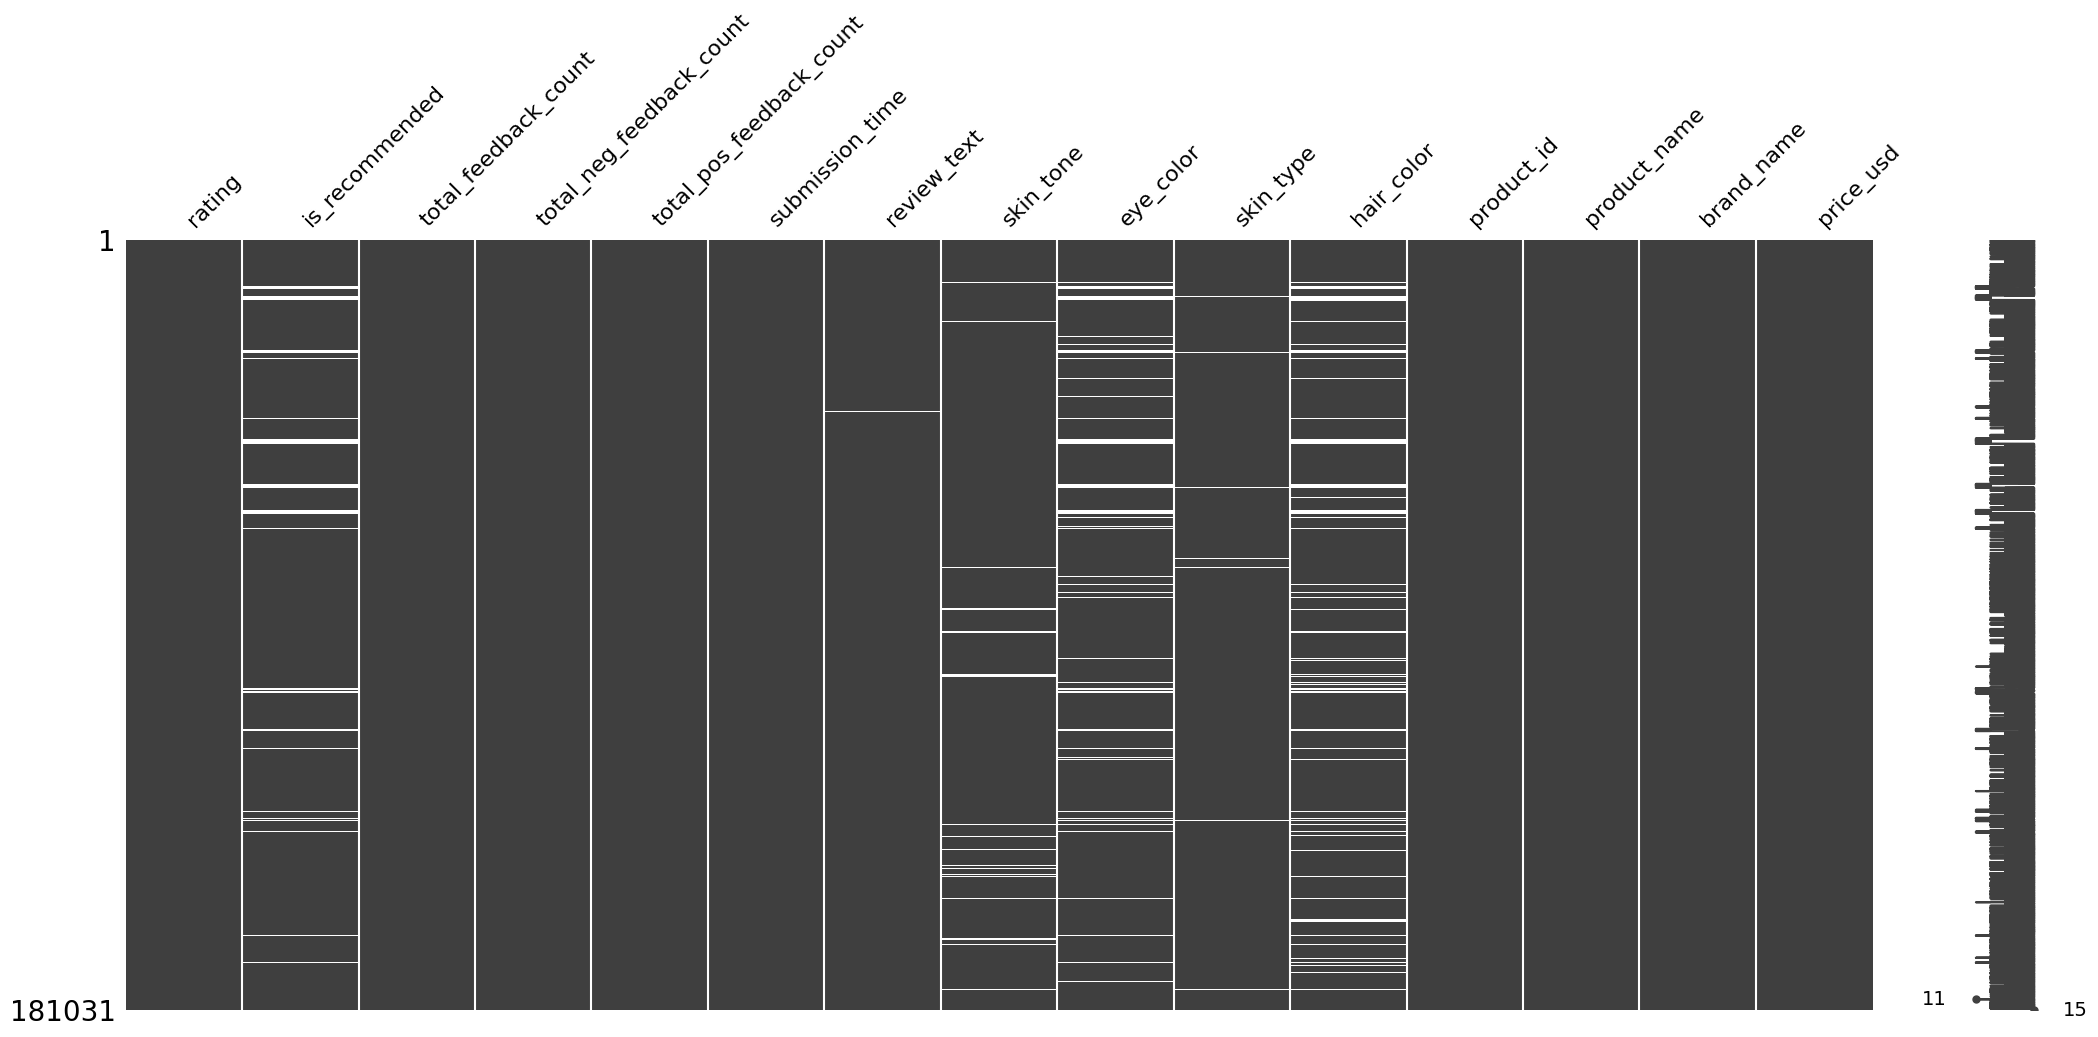

In [18]:
rows_to_drop3 = review[review['skin_type'].isna() & review['skin_tone'].isna() & review['eye_color'].isna() & review['hair_color'].isna()].index

review = review.drop(rows_to_drop3)
msno.matrix(review)

In [19]:
review.isna().sum()/review.shape[0]*100

rating                      0.000000
is_recommended              4.932857
total_feedback_count        0.000000
total_neg_feedback_count    0.000000
total_pos_feedback_count    0.000000
submission_time             0.000000
review_text                 0.124840
skin_tone                   2.458695
eye_color                   7.600908
skin_type                   0.543553
hair_color                  9.123852
product_id                  0.000000
product_name                0.000000
brand_name                  0.000000
price_usd                   0.000000
dtype: float64

# Skincare Dataset

<Axes: >

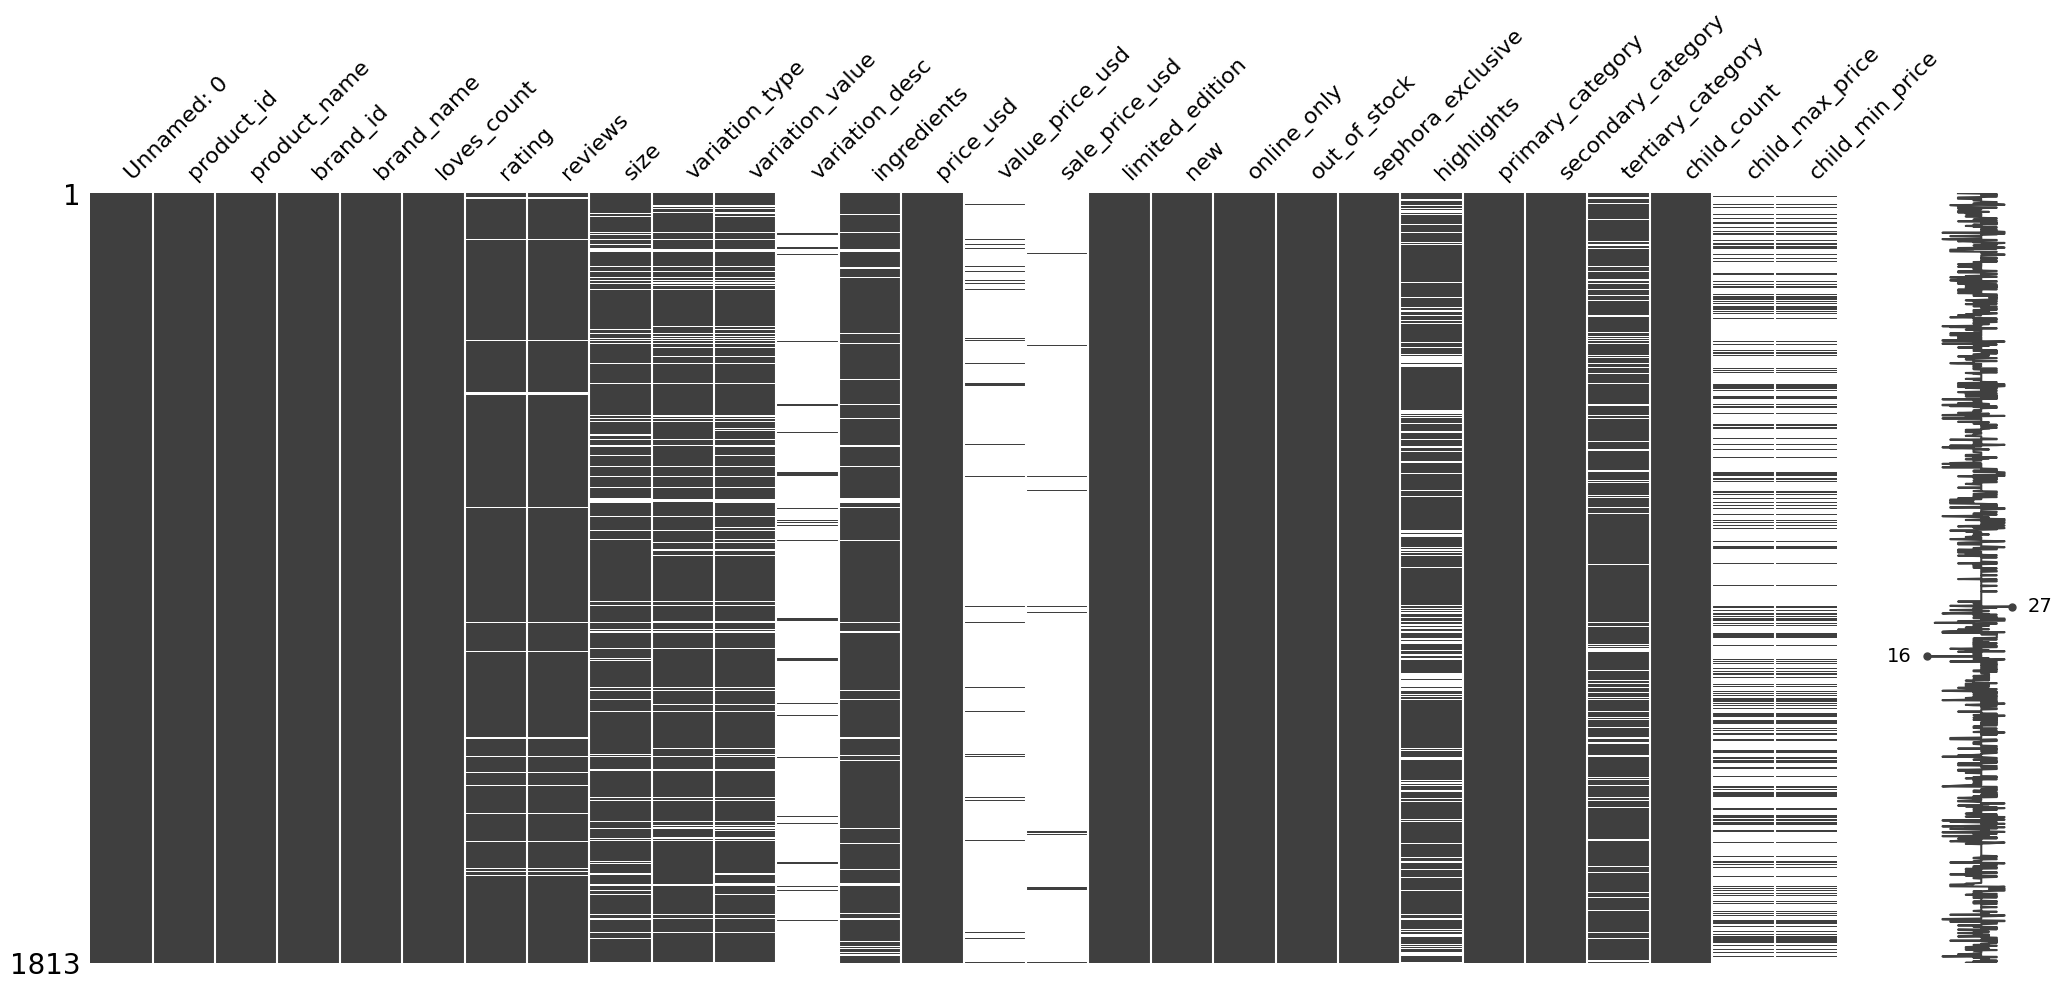

In [20]:
msno.matrix(skincare)

In [21]:
skincare.drop(['variation_desc', 'value_price_usd', 'sale_price_usd', 'child_max_price', 'child_min_price'], axis = 1, inplace = True)

<Axes: >

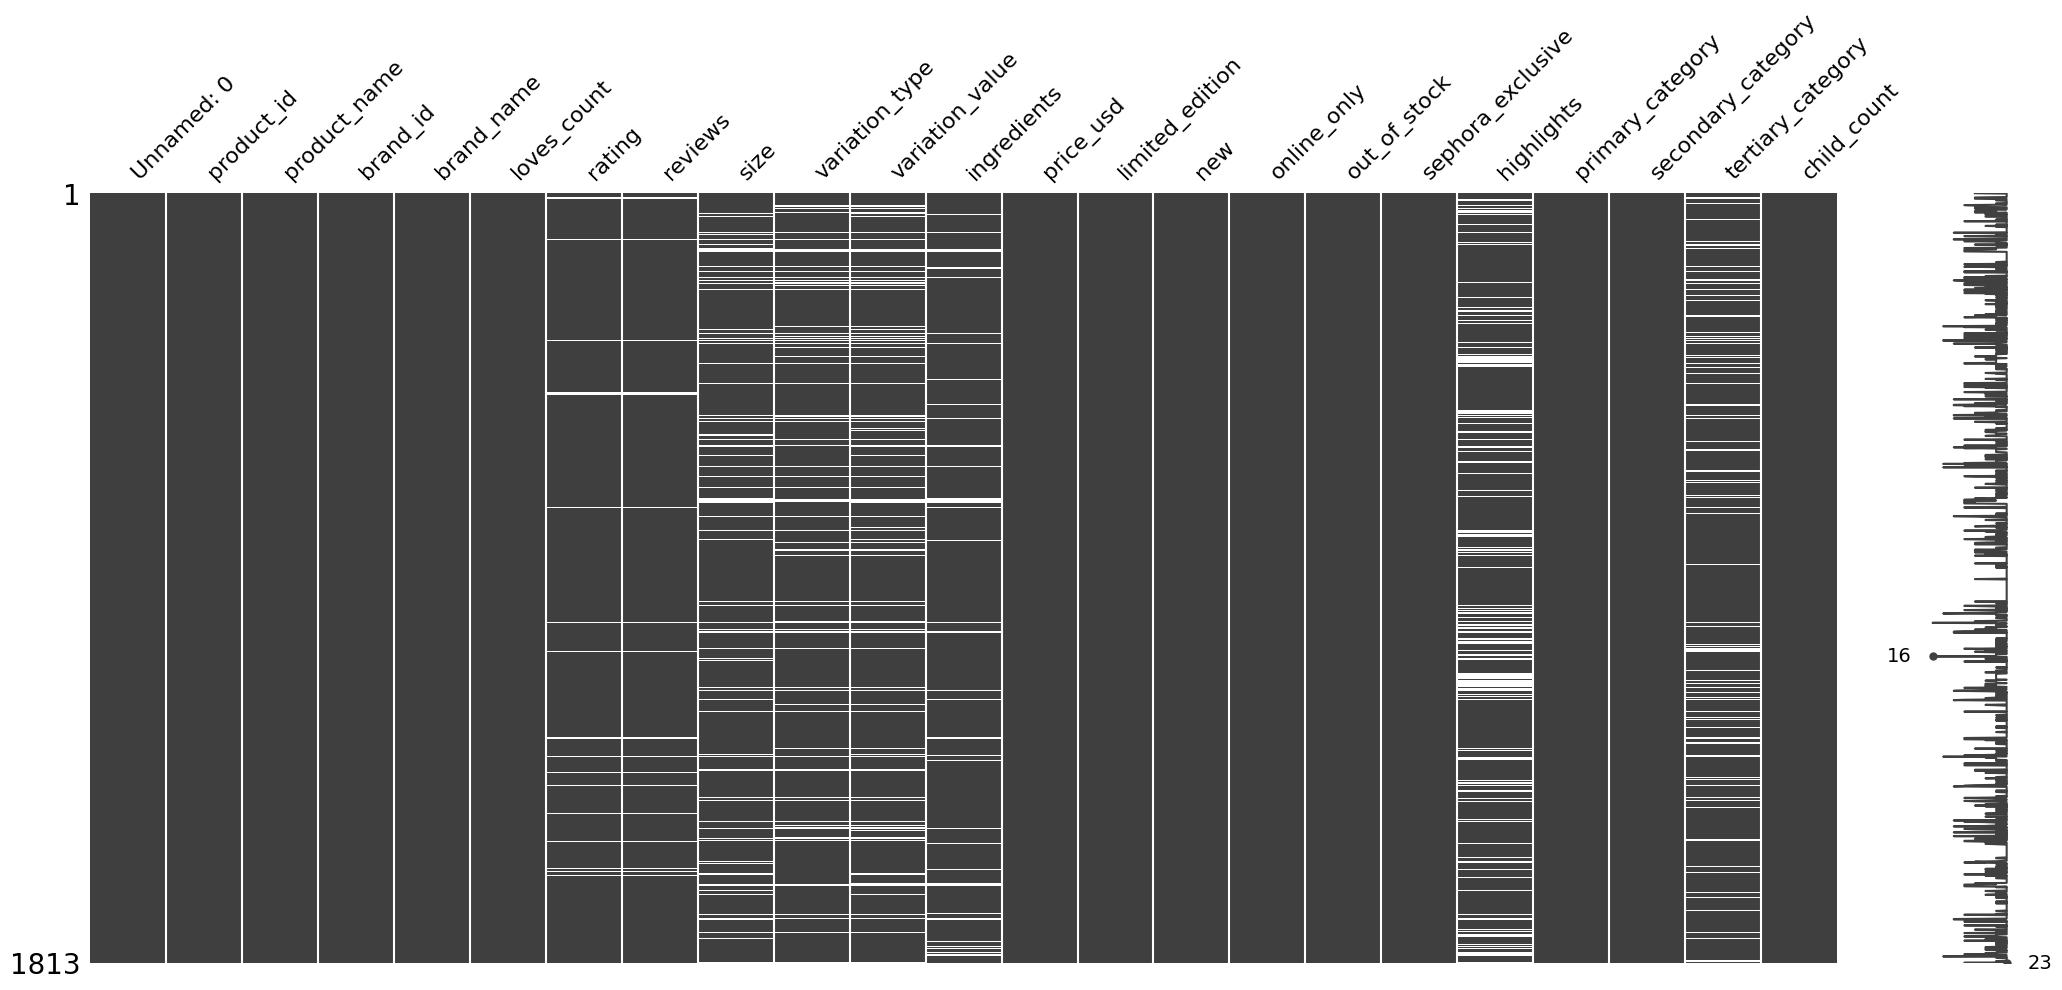

In [22]:
msno.matrix(skincare)

In [23]:
skincare.isna().sum()/skincare.shape[0]*100

Unnamed: 0             0.000000
product_id             0.000000
product_name           0.000000
brand_id               0.000000
brand_name             0.000000
loves_count            0.000000
rating                 2.647546
reviews                2.647546
size                  10.204082
variation_type         9.762824
variation_value       11.693326
ingredients            5.901820
price_usd              0.000000
limited_edition        0.000000
new                    0.000000
online_only            0.000000
out_of_stock           0.000000
sephora_exclusive      0.000000
highlights            18.532819
primary_category       0.000000
secondary_category     0.000000
tertiary_category     11.472697
child_count            0.000000
dtype: float64

In [24]:
skincare['primary_category'].value_counts()

primary_category
Hair               983
Skincare           551
Makeup             171
Mini Size           60
Bath & Body         21
Men                 12
Fragrance            9
Tools & Brushes      6
Name: count, dtype: int64

In [25]:
skincare = skincare[skincare['primary_category'] == 'Skincare']
skincare.shape

(551, 23)

<Axes: >

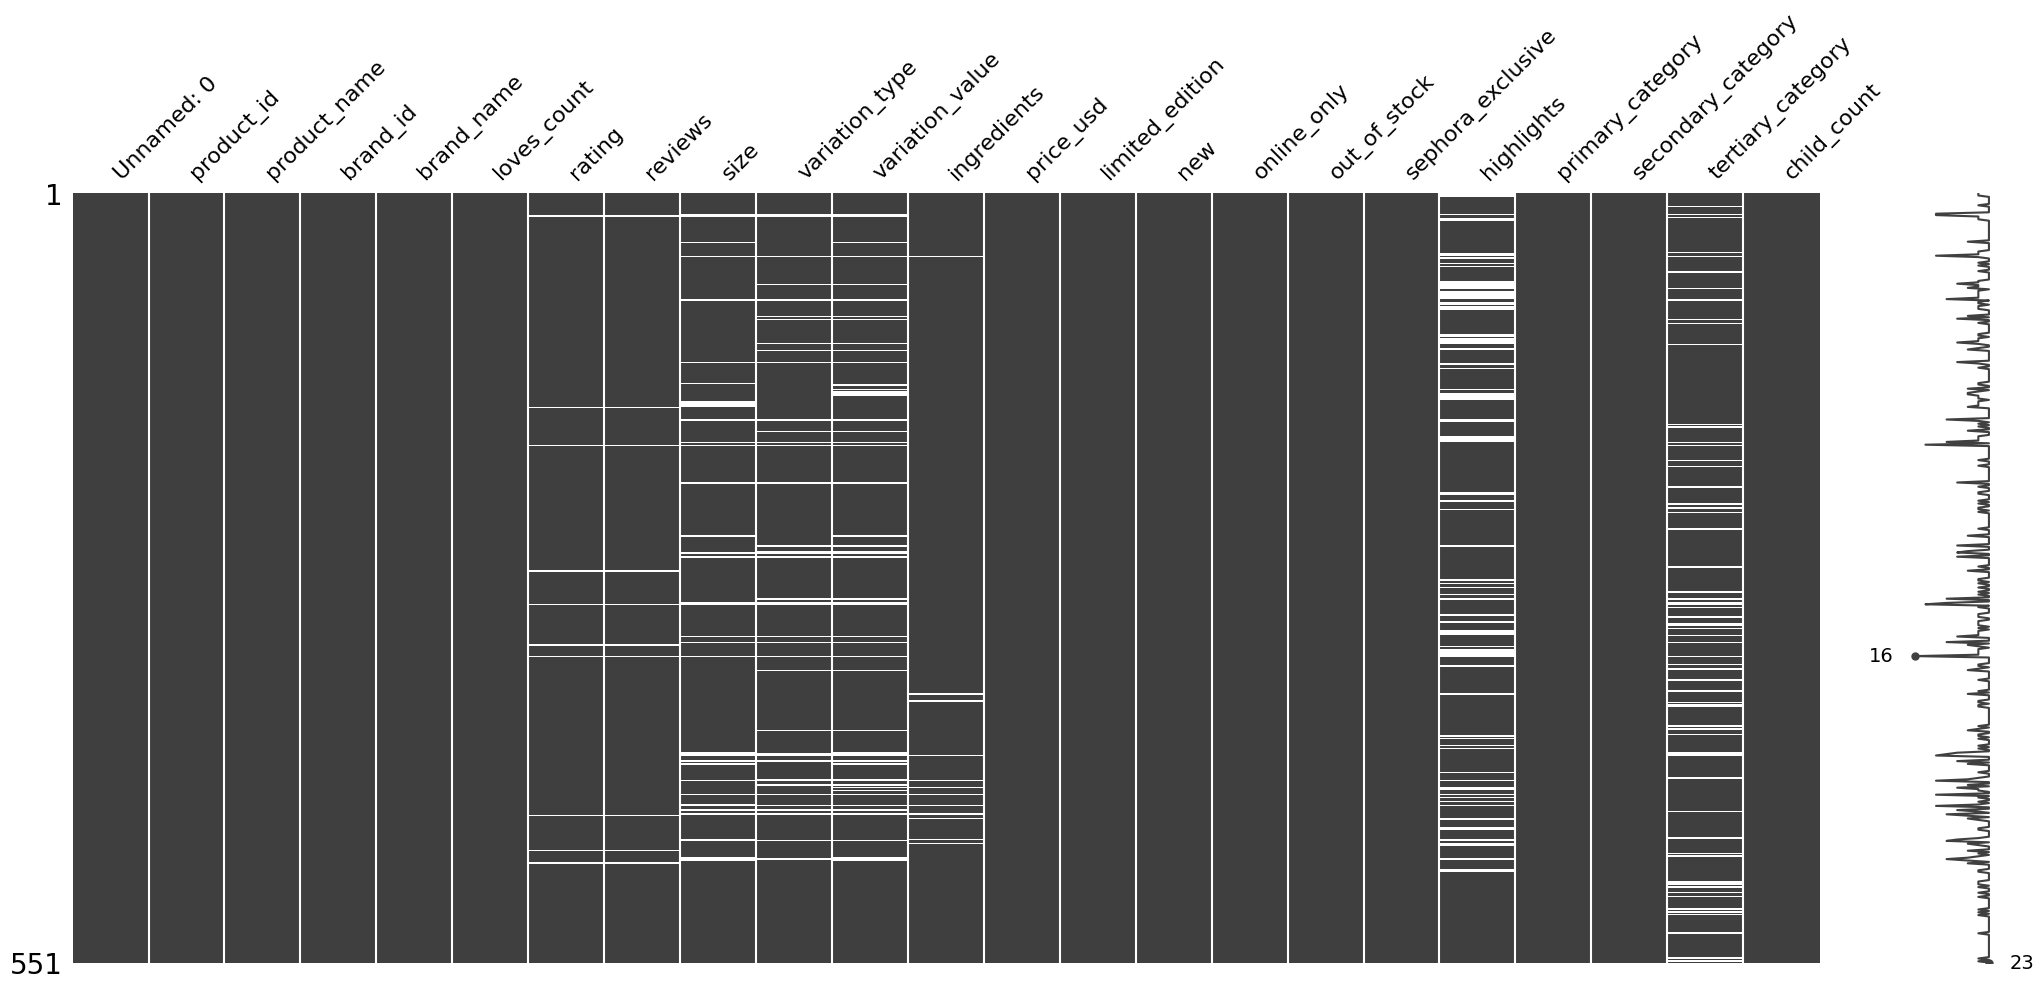

In [26]:
msno.matrix(skincare)

In [27]:
skincare.isna().sum()/skincare.shape[0]*100

Unnamed: 0             0.000000
product_id             0.000000
product_name           0.000000
brand_id               0.000000
brand_name             0.000000
loves_count            0.000000
rating                 1.814882
reviews                1.814882
size                   7.078040
variation_type         7.078040
variation_value        9.437387
ingredients            2.177858
price_usd              0.000000
limited_edition        0.000000
new                    0.000000
online_only            0.000000
out_of_stock           0.000000
sephora_exclusive      0.000000
highlights            17.967332
primary_category       0.000000
secondary_category     0.000000
tertiary_category     11.796733
child_count            0.000000
dtype: float64

In [28]:
skincare['highlights']

15                                                    NaN
16                                                    NaN
17                                                    NaN
18      ['Vegan', 'Hypoallergenic', 'Good for: Acne/Bl...
19      ['Best for Dry, Combo, Normal Skin', 'Good for...
                              ...                        
1806    ['Vegan', 'Refill Available', 'Good for: Pores...
1807    ['Refill Available', 'Community Favorite', 'Go...
1808    ['Vegan', 'Good for: Dullness/Uneven Texture',...
1809    ['Good for: Dullness/Uneven Texture', 'allure ...
1810    ['Vegan', 'Best for Oily Skin', 'Good for: Por...
Name: highlights, Length: 551, dtype: object

In [29]:
skincare.drop(['Unnamed: 0'], axis = 1, inplace = True)

In [30]:
for col in skincare.columns: 
    print(skincare[col].value_counts())

product_id
P388200    1
P443550    1
P440933    1
P502046    1
P440929    1
          ..
P501153    1
P427640    1
P417359    1
P392891    1
P470065    1
Name: count, Length: 551, dtype: int64
product_name
Lip Sleeping Mask                                                           2
GENIUS Ultimate Anti-Aging Melting Cleanser                                 1
Mega-Mushroom Skin Relief Micellar Cleanser                                 1
Out of Trouble 10 Minute Mask to Rescue Problem Skin                        1
Mini Clear Improvement Active Charcoal Mask to Clear Pore                   1
                                                                           ..
DayWear Eye Cooling Anti-Oxidant Moisture GelCreme                          1
Advanced Night Repair Concentrated Eye Treatment Mask                       1
Nutritious Super-Pomegranate Radiant Energy Night Moisturizer Creme/Mask    1
Micro Essence Infusion Mask                                                 1
Superclay Puri

In [31]:
skincare[skincare['product_name'] == 'Lip Sleeping Mask']
skincare.loc[(skincare['product_name'] == 'Lip Sleeping Mask') & (skincare['variation_value'] == 'Vanilla'), 'product_name'] = 'Vanilla Lip Sleeping Mask'
skincare.loc[(skincare['product_name'] == 'Lip Sleeping Mask') & (skincare['variation_value'] == 'Coconut'), 'product_name'] = 'Coconut Lip Sleeping Mask'

print(skincare[skincare['product_name'] == 'Vanilla Lip Sleeping Mask'])
print(skincare[skincare['product_name'] == 'Coconut Lip Sleeping Mask'])

     product_id               product_name  brand_id          brand_name  \
1488    P467652  Vanilla Lip Sleeping Mask      3902  SEPHORA COLLECTION   

      loves_count  rating  reviews           size variation_type  \
1488        45533  3.5475    316.0  0.5 oz/ 15 mL          Color   

     variation_value  ... limited_edition  new  online_only  out_of_stock  \
1488         Vanilla  ...               0    0            0             0   

      sephora_exclusive                                         highlights  \
1488                  1  ['Good for: Dryness', 'Vegan', 'Clean at Sepho...   

      primary_category      secondary_category tertiary_category child_count  
1488          Skincare  Lip Balms & Treatments               NaN           2  

[1 rows x 22 columns]
     product_id               product_name  brand_id          brand_name  \
1522    P500763  Coconut Lip Sleeping Mask      3902  SEPHORA COLLECTION   

      loves_count  rating  reviews            size variation_typ

In [32]:
skincare.drop(['limited_edition', 'new', 'online_only', 'out_of_stock', 'sephora_exclusive', 'primary_category'], axis = 1, inplace = True)

In [33]:
skincare[skincare['loves_count'] == 0]

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,ingredients,price_usd,highlights,secondary_category,tertiary_category,child_count
518,P455915,Mini MultiVitamin Power Recovery Mask,6219,Dermalogica,0,5.0000,2.0,0.5 oz/ 15 mL,Size,0.5 oz/ 15 mL,"['Palmitoyl Oligopeptide, Palmitoyl Tetrapepti...",16.5,"['Good for: Dark Circles', 'Good for: Loss of ...",Mini Size,NaN,0
567,P457011,Cryo Rubber Mask with Firming Collagen,6014,Dr. Jart+,0,4.8462,13.0,NaN,Type,0.14 oz/ 4 g Ampoule + 1.41 oz/ 40 g Rubber Ma...,"['Step 1 Dr.Jart Collagen 1000 ppm Ampoule:', ...",15.0,"['Collagen', 'Hyaluronic Acid', 'Vitamin C', '...",Masks,Face Masks,0
568,P457012,Cryo Rubber Mask with Brightening Vitamin C,6014,Dr. Jart+,0,3.8333,12.0,NaN,Type,0.14 oz/ 4 g Ampoule + 1.41 oz/ 40 g Rubber Ma...,"['Step 1 Dr.Jart Vitamin C 1000 ppm Ampoule:',...",15.0,"['Collagen', 'Hyaluronic Acid', 'Vitamin C', '...",Masks,Face Masks,0
569,P457010,Cryo Rubber Mask with Soothing Allantoin,6014,Dr. Jart+,0,4.5556,9.0,NaN,Type,0.14 oz/ 4 g Ampoule + 1.41 oz/ 40 g Rubber Ma...,['Step One Dr.Jart Allantoin 1000 PPM Ampoule:...,15.0,"['Collagen', 'Hyaluronic Acid', 'Vitamin C', '...",Masks,Face Masks,0
570,P457009,Cryo Rubber Mask with Moisturizing Hyaluronic ...,6014,Dr. Jart+,0,4.0000,6.0,NaN,Type,0.14 oz/ 4 g Ampoule + 1.41 oz/ 40 g Rubber Ma...,['Step 1 Dr.Jart Hyaluronic Acid 1000 ppm Ampo...,15.0,"['Collagen', 'Hyaluronic Acid', 'Vitamin C', '...",Masks,Face Masks,0
714,P429538,Lotus Youth Preseve Rescue Mask Mini,4348,fresh,0,4.2667,15.0,1 oz/ 30 mL,Size,1 oz/ 30 mL,"['Water, Glycerin, Propylene Glycol Dicaprylat...",28.0,NaN,Shop by Concern,Anti-Aging,0
716,P432255,Mini Black Tea Firming Overnight Mask,4348,fresh,0,4.0000,3.0,1 oz/ 30 mL,Size,1 oz/ 30 mL,"['Water, Glycerin, Butylene Glycol, Jojoba Est...",40.0,"['Hyaluronic Acid', 'Good for: Loss of firmnes...",Mini Size,NaN,0
1506,P446820,Grapefruit Peeling Mask - Skin Perfection,3902,SEPHORA COLLECTION,0,3.4444,36.0,1.69oz/ 50 mL,Type,Grapefruit Peeling,"['Water, Glycerin, Sodium Acrylates Copolymer,...",8.0,NaN,Masks,Face Masks,0
1509,P446822,Hemp Mousse Mask - Anti-Blemish,3902,SEPHORA COLLECTION,0,3.5769,26.0,1.69oz/ 50 mL,Type,Hemp Mousse,"['Water, Glycerin, Cannabis Sativa Seed Oil, T...",8.0,NaN,Masks,Face Masks,0


In [34]:
skincare[(skincare['size'] != skincare['variation_value'])]

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,ingredients,price_usd,highlights,secondary_category,tertiary_category,child_count
108,P463792,Rejuvenating Scalp + Fuller Hair Therapy Set,6272,BeautyBio,5810,3.5385,13.0,NaN,NaN,NaN,"['Healthy Scalp Serum:', 'Water/Aqua/Eau, Glyc...",249.0,NaN,Value & Gift Sets,NaN,0
109,P500755,Cryo Skin Icing Roller + Bright Eyes Gels Set,6272,BeautyBio,876,NaN,NaN,NaN,NaN,NaN,"['Bright Eyes Eye Gels:', 'Aqua, Glycerin, Col...",100.0,"['Good for: Loss of firmness', 'Good for: Pore...",High Tech Tools,Anti-Aging,0
321,P471009,Vinoperfect Brightening Glycolic Peel Mask,4171,Caudalie,19999,4.5365,192.0,NaN,Size,NaN,"['Aqua/Water/Eau, Glycerin, Coco-Caprylate/Cap...",42.0,"['Vegan', 'Good for: Dullness/Uneven Texture',...",Masks,Face Masks,0
354,P476842,Cryo-Recovery Lifting Face Mask with Acupressu...,6236,Charlotte Tilbury,15090,2.8077,26.0,NaN,NaN,NaN,NaN,55.0,"['Good for: Loss of firmness', 'Good for: Anti...",High Tech Tools,NaN,0
384,P201439,Redness Solutions Soothing Cleanser,1254,CLINIQUE,9881,4.1672,287.0,5 oz/ 150 mL,NaN,NaN,"['Water, Squalane, Glycerin, Butylene Glycol, ...",26.5,NaN,Cleansers,Face Wash & Cleansers,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1575,P477761,Lovely Lashes Contour Sleep Mask,6130,Slip,3771,4.0000,8.0,NaN,NaN,NaN,['Outer 100% silk (exclusive of elastic and pi...,55.0,NaN,Wellness,Holistic Wellness,0
1602,P475172,Overnight Vitalizing Mask,6307,Sulwhasoo,12664,4.7170,106.0,NaN,Size,NaN,"['Water/Aqua/Eau, Butylene Glycol, Glycerin, C...",54.0,"['Good for: Dullness/Uneven Texture', 'Best fo...",Masks,Face Masks,0
1603,P463110,Clarifying Peel Off Mask,6307,Sulwhasoo,2963,4.5000,10.0,NaN,NaN,NaN,"['Water / Aqua / Eau, Polyvinyl Alcohol, Alcoh...",45.0,NaN,Masks,Face Masks,0
1604,P463109,Overnight Vitalizing Sleeping Mask,6307,Sulwhasoo,259,3.2500,4.0,NaN,Size,NaN,"['Water/Aqua/Eau, Butylene Glycol, Glycerin, C...",54.0,"['Good for: Dullness/Uneven Texture', 'Best fo...",Masks,Face Masks,0


In [35]:
skincare.drop(['variation_type', 'variation_value'], axis = 1, inplace = True)

In [36]:
# Extract numeric values followed by 'oz' (with optional spaces)
skincare['size (oz)'] = skincare['size'].str.extract(r'([\d.]+)\s*oz', expand=False)

# Convert to float
skincare['size (oz)'] = pd.to_numeric(skincare['size (oz)'], errors='coerce')

In [37]:
print(skincare.loc[skincare['size (oz)'].isna(), ['product_name', 'secondary_category', 'size', 'size (oz)']])

                                           product_name secondary_category  \
104   Bright Eyes Collagen-Infused Brightening Collo...           Eye Care   
108        Rejuvenating Scalp + Fuller Hair Therapy Set  Value & Gift Sets   
109       Cryo Skin Icing Roller + Bright Eyes Gels Set    High Tech Tools   
321          Vinoperfect Brightening Glycolic Peel Mask              Masks   
352                 Instant Magic Facial Dry Sheet Mask              Masks   
...                                                 ...                ...   
1602                          Overnight Vitalizing Mask              Masks   
1603                           Clarifying Peel Off Mask              Masks   
1604                 Overnight Vitalizing Sleeping Mask              Masks   
1797                            Baggage Claim Eye Masks           Eye Care   
1800                  Baggage Claim Rose Gold Eye Masks           Eye Care   

               size  size (oz)  
104        15 pairs        NaN

In [38]:
skincare.columns

Index(['product_id', 'product_name', 'brand_id', 'brand_name', 'loves_count',
       'rating', 'reviews', 'size', 'ingredients', 'price_usd', 'highlights',
       'secondary_category', 'tertiary_category', 'child_count', 'size (oz)'],
      dtype='object')

In [39]:
skincare.drop(['child_count'], axis = 1, inplace = True)

In [40]:
skincare.columns

Index(['product_id', 'product_name', 'brand_id', 'brand_name', 'loves_count',
       'rating', 'reviews', 'size', 'ingredients', 'price_usd', 'highlights',
       'secondary_category', 'tertiary_category', 'size (oz)'],
      dtype='object')

In [41]:
review.drop(['submission_time', 'eye_color', 'hair_color'], axis = 1, inplace = True)

In [42]:
review.columns

Index(['rating', 'is_recommended', 'total_feedback_count',
       'total_neg_feedback_count', 'total_pos_feedback_count', 'review_text',
       'skin_tone', 'skin_type', 'product_id', 'product_name', 'brand_name',
       'price_usd'],
      dtype='object')

In [43]:
# rev = review.merge(skincare, on='product_id', how='left')

In [44]:
# rev.head()

In [45]:
# msno.matrix(rev)

In [46]:
# rev.isna().sum()/rev.shape[0]

In [47]:
# all(rev.brand_name_x == rev.brand_name_y)
# rev.rename(columns = {'brand_name_x': 'brand_name'}, inplace = True)

In [48]:
# all(rev.product_name_x == rev.product_name_y)

In [49]:
# all(rev.price_usd_x == rev.price_usd_y)
# rev.rename(columns = {'price_usd_x': 'price_usd'}, inplace = True)

In [50]:
# rev.rename(columns = {'rating_y': 'avg_rating'}, inplace = True)
# rev.rename(columns = {'rating_x': 'rating'}, inplace = True)

In [51]:
# rev.columns

In [52]:
# rev.loc[rev['product_name_x'] != rev['product_name_y'], ['product_name_x', 'product_name_y']]

In [53]:
# rev.rename(columns = {'product_name_y': 'product_name'}, inplace = True)

In [54]:
# rev.columns

In [55]:
# rev.drop(['brand_name_y', 'price_usd_y', 'product_name_x'], axis = 1, inplace = True)

In [56]:
# rev.columns

In [57]:
# Check current NAs now
missing_count = skincare.isna().sum()
missing_per = skincare.isna().sum() / len(skincare) * 100

na_summary = pd.DataFrame( {
     'Missing Count': missing_count,
     'Missing Percentage': missing_per,
     'Data Type': skincare.dtypes
})

na_summary = na_summary[na_summary['Missing Count'] > 0].sort_values('Missing Percentage', ascending=False)
print(na_summary)


                   Missing Count  Missing Percentage Data Type
highlights                    99           17.967332    object
size (oz)                     96           17.422868   float64
tertiary_category             65           11.796733    object
size                          39            7.078040    object
ingredients                   12            2.177858    object
rating                        10            1.814882   float64
reviews                       10            1.814882   float64


In [58]:
# Fix NAs for tertiary category 
skincare['tertiary_category'].value_counts(dropna=False)

tertiary_category
Face Wash & Cleansers        156
Face Masks                   131
Moisturizers                  72
NaN                           65
Sheet Masks                   31
Eye Creams & Treatments       24
Face Serums                   19
Eye Masks                     11
Blemish & Acne Treatments      7
For Body                       4
Face Sunscreen                 4
Anti-Aging                     3
Face Oils                      3
Makeup Removers                3
Exfoliators                    3
Facial Peels                   3
Holistic Wellness              3
Night Creams                   2
Toners                         2
For Face                       1
BB & CC Creams                 1
Beauty Supplements             1
Facial Cleansing Brushes       1
Decollete & Neck Creams        1
Name: count, dtype: int64

In [59]:
skincare['secondary_category'].value_counts(dropna=False)

secondary_category
Cleansers                 167
Masks                     162
Moisturizers               79
Mini Size                  36
Eye Care                   35
Treatments                 29
Value & Gift Sets          13
Lip Balms & Treatments     12
Self Tanners                5
High Tech Tools             4
Sunscreen                   4
Wellness                    4
Shop by Concern             1
Name: count, dtype: int64

In [60]:
# Fill missing tertiary_category with secondary_category
skincare['tertiary_category'] = skincare['tertiary_category'].fillna(skincare['secondary_category'])
print(f"Missing tertiary_category: {skincare['tertiary_category'].isna().sum()}")

secondary_counts = skincare['secondary_category'].value_counts()
tertiary_counts = skincare['tertiary_category'].value_counts()
comparison_df = pd.DataFrame({
    'Secondary_Category_Count': secondary_counts,
    'Tertiary_Category_Count': tertiary_counts
}).fillna(0).astype(int)

comparison_df = comparison_df.sort_values('Secondary_Category_Count', ascending=False)
print(comparison_df)
print(f"Secondary Counts: {secondary_counts.sum()}")
print(f"Tertiary Counts: {tertiary_counts.sum()}")

Missing tertiary_category: 0
                           Secondary_Category_Count  Tertiary_Category_Count
Cleansers                                       167                        3
Masks                                           162                        0
Moisturizers                                     79                       72
Mini Size                                        36                       36
Eye Care                                         35                        0
Treatments                                       29                        0
Value & Gift Sets                                13                       13
Lip Balms & Treatments                           12                       12
Self Tanners                                      5                        0
Wellness                                          4                        0
Sunscreen                                         4                        0
High Tech Tools                                

Missing Categories that got filled 
- Mini Size
- Lip Balms & Treatments 
- Value & Gift Sets 
- Cleansers 


In [61]:
# Value & Gifts
skincare[skincare['secondary_category'] == 'Mini Size'][['product_name', 'secondary_category', 'tertiary_category']]

,product_name,secondary_category,tertiary_category
371,Mini Take The Day Off Cleansing Balm Makeup Re...,Mini Size,Mini Size
503,Mini Special Cleansing Gel,Mini Size,Mini Size
518,Mini MultiVitamin Power Recovery Mask,Mini Size,Mini Size
590,Mini Beste No. 9 Jelly Cleanser,Mini Size,Mini Size
623,Mini Advanced Night Repair Synchronized Multi-...,Mini Size,Mini Size
676,Mini Total Cleans'r Makeup Removing Cleanser,Mini Size,Mini Size
713,Mini Black Tea Instant Perfecting Mask,Mini Size,Mini Size
716,Mini Black Tea Firming Overnight Mask,Mini Size,Mini Size
754,Mini Blueberry Bounce Gentle Cleanser,Mini Size,Mini Size
835,Mini Confidence in a Cleanser,Mini Size,Mini Size


In [62]:
# Remove all rows with Value & Gift Sets
rows_to_drop = skincare[skincare['secondary_category'] == 'Value & Gift Sets'].index
skincare = skincare.drop(rows_to_drop) 

In [63]:
# Mini Size (keep or?)
skincare[skincare['secondary_category'] == 'Mini Size'][['product_name', 'secondary_category', 'tertiary_category']]

,product_name,secondary_category,tertiary_category
371,Mini Take The Day Off Cleansing Balm Makeup Re...,Mini Size,Mini Size
503,Mini Special Cleansing Gel,Mini Size,Mini Size
518,Mini MultiVitamin Power Recovery Mask,Mini Size,Mini Size
590,Mini Beste No. 9 Jelly Cleanser,Mini Size,Mini Size
623,Mini Advanced Night Repair Synchronized Multi-...,Mini Size,Mini Size
676,Mini Total Cleans'r Makeup Removing Cleanser,Mini Size,Mini Size
713,Mini Black Tea Instant Perfecting Mask,Mini Size,Mini Size
716,Mini Black Tea Firming Overnight Mask,Mini Size,Mini Size
754,Mini Blueberry Bounce Gentle Cleanser,Mini Size,Mini Size
835,Mini Confidence in a Cleanser,Mini Size,Mini Size


In [64]:
# Cleansers
skincare[skincare['secondary_category'] == 'Cleansers'][['product_name', 'secondary_category', 'tertiary_category']]

,product_name,secondary_category,tertiary_category
15,GENIUS Ultimate Anti-Aging Melting Cleanser,Cleansers,Face Wash & Cleansers
16,Gentle Rejuvenating Cleanser,Cleansers,Face Wash & Cleansers
19,Balancing Cleanser,Cleansers,Face Wash & Cleansers
20,Triple Action Cleanser,Cleansers,Face Wash & Cleansers
22,Juneberry & Collagen Hydrating Cold Cream Clea...,Cleansers,Face Wash & Cleansers
...,...,...,...
1697,Gentle Micellar Antioxidant Cleanser,Cleansers,Face Wash & Cleansers
1701,The Cult Classic Purifying Face Cleanser,Cleansers,Face Wash & Cleansers
1702,Mini The Cult Classic Purifying Face Cleanser,Cleansers,Face Wash & Cleansers
1802,SHIKULIME Gel-to-Oil Cleanser,Cleansers,Face Wash & Cleansers


In [65]:
# Change all "Cleansers" in tertiary_category to "Face Wash & Cleansers"
skincare.loc[skincare['tertiary_category'] == 'Cleansers', 'tertiary_category'] = 'Face Wash & Cleansers'
skincare[skincare['secondary_category'] == 'Cleansers'][['product_name', 'secondary_category', 'tertiary_category']]

,product_name,secondary_category,tertiary_category
15,GENIUS Ultimate Anti-Aging Melting Cleanser,Cleansers,Face Wash & Cleansers
16,Gentle Rejuvenating Cleanser,Cleansers,Face Wash & Cleansers
19,Balancing Cleanser,Cleansers,Face Wash & Cleansers
20,Triple Action Cleanser,Cleansers,Face Wash & Cleansers
22,Juneberry & Collagen Hydrating Cold Cream Clea...,Cleansers,Face Wash & Cleansers
...,...,...,...
1697,Gentle Micellar Antioxidant Cleanser,Cleansers,Face Wash & Cleansers
1701,The Cult Classic Purifying Face Cleanser,Cleansers,Face Wash & Cleansers
1702,Mini The Cult Classic Purifying Face Cleanser,Cleansers,Face Wash & Cleansers
1802,SHIKULIME Gel-to-Oil Cleanser,Cleansers,Face Wash & Cleansers


In [66]:
# Check current NAs now
missing_count = skincare.isna().sum()
missing_per = skincare.isna().sum() / len(skincare) * 100

na_summary = pd.DataFrame( {
    'Missing Count': missing_count,
    'Missing Percentage': missing_per,
    'Data Type': skincare.dtypes
})

na_summary = na_summary[na_summary['Missing Count'] > 0].sort_values('Missing Percentage', ascending=False)
print(na_summary)

             Missing Count  Missing Percentage Data Type
highlights              97           18.029740    object
size (oz)               84           15.613383   float64
size                    28            5.204461    object
ingredients             11            2.044610    object
rating                   7            1.301115   float64
reviews                  7            1.301115   float64


In [67]:
skincare.head()

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,ingredients,price_usd,highlights,secondary_category,tertiary_category,size (oz)
15,P388200,GENIUS Ultimate Anti-Aging Melting Cleanser,6018,Algenist,9314,4.0569,334.0,5 oz/ 150 mL,"['C12-15 Alkyl Benzoate, Ethylhexyl Palmitate,...",38.0,NaN,Cleansers,Face Wash & Cleansers,5.00
16,P296413,Gentle Rejuvenating Cleanser,6018,Algenist,7681,4.2689,264.0,4 oz/ 120 mL,"['Water, Sodium Cocoyl Isethionate, Glyceryl S...",28.0,NaN,Cleansers,Face Wash & Cleansers,4.00
17,P379907,Advanced Anti-Aging Repairing Oil,6018,Algenist,10676,4.4531,245.0,1 oz/ 30 mL,"['Chlorella Protothecoides Oil, Cetearyl Ethyl...",82.0,NaN,Moisturizers,Face Oils,1.00
18,P442859,ALIVE Prebiotic Balancing Mask,6018,Algenist,14367,4.3729,118.0,1.7 oz/ 50 mL,"['Glycerin, Water (Aqua, Eau), Sodium Cocoyl G...",38.0,"['Vegan', 'Hypoallergenic', 'Good for: Acne/Bl...",Masks,Face Masks,1.70
19,P442546,Balancing Cleanser,6283,Alpha-H,3612,4.5455,77.0,6.25 oz/ 185 mL,"['Water, Ethylhexyl Palmitate, Aloe Barbadensi...",38.0,"['Best for Dry, Combo, Normal Skin', 'Good for...",Cleansers,Face Wash & Cleansers,6.25


In [68]:
skincare.drop(['product_id', 'brand_id', 'size'], axis = 1, inplace = True)
review.drop(['product_id'], axis = 1, inplace = True)

In [69]:
skincare.columns[skincare.dtypes == object]

Index(['product_name', 'brand_name', 'ingredients', 'highlights',
       'secondary_category', 'tertiary_category'],
      dtype='object')

In [70]:
review['skin_tone'].value_counts()

skin_tone
light          50679
fair           40331
lightMedium    36714
medium         13673
mediumTan      11854
fairLight      10648
tan             6563
deep            3973
rich            1094
porcelain        497
olive            419
dark             118
notSureST         14
ebony              3
Name: count, dtype: int64

In [71]:
# mapping skin_tone into three categories
def create_binary_columns(tone):
    tone = str(tone).lower()
    
    light = 0
    medium = 0
    deep = 0
    
    # Light skin tones
    if tone in ['light', 'fair', 'fairlight', 'porcelain', 'olive']:
        light = 1
    
    # Medium skin tones
    elif tone in ['lightmedium', 'medium', 'mediumtan', 'tan']:
        medium = 1
    
    # Deep skin tones
    elif tone in ['deep', 'rich', 'dark', 'ebony']:
        deep = 1
    
    # Unknown - set all to 0 or handle differently
    # else: all remain 0
    
    return pd.Series([light, medium, deep])

review[['skin_light', 'skin_medium', 'skin_deep']] = review['skin_tone'].apply(create_binary_columns)


In [72]:
review['skin_type'].value_counts()

skin_type
combination    100620
dry             32990
oily            23219
normal          23218
Name: count, dtype: int64

In [73]:
def create_skin_type_binary(skin_type):
    skin_type = str(skin_type).lower()
    
    combination = 0
    dry = 0
    normal = 0
    oily = 0
    
    # Assign based on skin type
    if skin_type == 'combination':
        combination = 1
    elif skin_type == 'dry':
        dry = 1
    elif skin_type == 'normal':
        normal = 1
    elif skin_type == 'oily':
        oily = 1
    
    return pd.Series([combination, dry, normal, oily])

review[['skin_combination', 'skin_dry', 'skin_normal', 'skin_oily']] = review['skin_type'].apply(create_skin_type_binary)

In [74]:
review.drop(['skin_type', 'skin_tone'], axis = 1, inplace = True)

In [75]:
print(review.columns[review.dtypes == object])
print(skincare.columns[skincare.dtypes == object])

Index(['review_text', 'product_name', 'brand_name'], dtype='object')
Index(['product_name', 'brand_name', 'ingredients', 'highlights',
       'secondary_category', 'tertiary_category'],
      dtype='object')


In [76]:
skincare.isna().mean()

product_name          0.000000
brand_name            0.000000
loves_count           0.000000
rating                0.013011
reviews               0.013011
ingredients           0.020446
price_usd             0.000000
highlights            0.180297
secondary_category    0.000000
tertiary_category     0.000000
size (oz)             0.156134
dtype: float64

In [77]:
skincare.loc[skincare['rating'].isna(), 'rating'] = skincare['rating'].median()
skincare.loc[skincare['reviews'].isna(), 'reviews'] = skincare['reviews'].median()

In [78]:
skincare.isna().mean()

product_name          0.000000
brand_name            0.000000
loves_count           0.000000
rating                0.000000
reviews               0.000000
ingredients           0.020446
price_usd             0.000000
highlights            0.180297
secondary_category    0.000000
tertiary_category     0.000000
size (oz)             0.156134
dtype: float64

In [79]:
review.isna().mean()

rating                      0.000000
is_recommended              0.049329
total_feedback_count        0.000000
total_neg_feedback_count    0.000000
total_pos_feedback_count    0.000000
review_text                 0.001248
product_name                0.000000
brand_name                  0.000000
price_usd                   0.000000
skin_light                  0.000000
skin_medium                 0.000000
skin_deep                   0.000000
skin_combination            0.000000
skin_dry                    0.000000
skin_normal                 0.000000
skin_oily                   0.000000
dtype: float64

In [80]:
# fill is_recommended NAs based on rating (not finished)
review['is_recommended'].value_counts()

is_recommended
1.0    144959
0.0     27142
Name: count, dtype: int64

In [83]:
# exporting dataset for text-mining
skincare.to_csv("dataset/skincare.csv")
review.to_csv("dataset/review.csv")